### Arquitectura F-SPDENO 2D — Navier–Stokes ($W \mapsto X$)

Reconstrucción de la solución vía expansión de Wiener–caos (WCE): la estocasticidad se codifica en
*features de Wick* deterministas y un **FNO 2D** aprende los propagadores. Flujo (Fig. 2, Shi et al. 2026):

$$
W(t,x) \;\xrightarrow{\text{Wick}}\; \eta(W)=\{\xi_\alpha\}_{|\alpha|\le M}
\;\xrightarrow{\text{FNO 2D}}\; \{C_k(x)\}
\;\xrightarrow{\text{Haar}}\; \hat u(t,x)=\sum_k C_k(x)\,\phi_k(t)
$$

**Diferencias con el caso 1D ($\Phi^4_1$):**
1. **Features de Wick 2D:** los modos espaciales $f_m$ son modos de **Fourier 2D** (cos/sen de
   vectores de onda $k=(k_1,k_2)$), no senos 1D. Se eligen los de menor $|k|$ (los que concentran la
   energía del ruido coloreado). El resto del pipeline (coordenadas gaussianas $\xi_{m,j}$ + monomios
   de Hermite) es idéntico.
2. **FNO 2D:** convolución espectral 2D (`rfft2`); la salida son campos $C_k(x_1,x_2)$.
3. **Reconstrucción:** $\hat u(t,x_1,x_2)=\sum_k C_k(x_1,x_2)\,\phi_k(t)$ con $\{\phi_k\}$ base de Haar
   **temporal** (1D en $t$), igual que en 1D.
4. **Entrada del FNO por lotes:** las features de Wick son escalares por muestra; en 2D no se pre-difunden
   a un tensor gigante $(N,s,s,P)$ sino que se difunden **por mini-batch** (ahorro de memoria).

In [1]:
import math
from math import factorial
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from numpy.polynomial.hermite_e import hermeval   # Hermite probabilista h_k (He)

torch.manual_seed(0); np.random.seed(0)
torch.set_num_threads(6)
device = "cuda" if torch.cuda.is_available() else "cpu"

# ---------------- CONFIG ÚNICA ----------------
# Modos espaciales de Wick: vectores de onda 2D (se usan cos y sen de cada uno -> 2 modos c/u).
KVECS    = [(1, 0), (0, 1), (1, 1), (1, -1), (2, 0), (0, 2)]   # -> S = 12 modos reales
TM       = 3      # nº de modos TEMPORALES e_j de las coordenadas del ruido
M        = 2      # orden de Hermite / caos (paper NS: M=2).  #features = C(S*TM+M, M)
K_HAAR   = 24     # nº de funciones de Haar phi_k (propagadores).  Paper: 256 (grilla más fina)
WIDTH    = 32     # ancho latente del FNO 2D.  Paper: 64
MODES    = 8      # modos de Fourier retenidos por capa espectral (por dimensión)
N_LAYERS = 6      # nº de capas de Fourier
EPOCHS   = 25     # paper NS: 30 épocas (aquí 25; satura ~ep15)
BS       = 20
LR       = 1e-3
WD       = 0.0    # SIN weight decay: con la pérdida L2 RELATIVA (gradiente normalizado),
                  # el wd=3e-4 del paper domina el gradiente y colapsa la red a salida 0.
GRAD_CLIP = 1.0   # recorte de norma de gradiente (estabilidad)

print("device:", device)
print(f"KVECS={KVECS} (S={2*len(KVECS)}) TM={TM} M={M} K_HAAR={K_HAAR} "
      f"WIDTH={WIDTH} MODES={MODES} N_LAYERS={N_LAYERS}")


device: cpu
KVECS=[(1, 0), (0, 1), (1, 1), (1, -1), (2, 0), (0, 2)] (S=12) TM=3 M=2 K_HAAR=24 WIDTH=32 MODES=8 N_LAYERS=6


In [2]:
# ============ Carga de datos:  W (Q-Browniano), X (vorticidad) ============
data = np.load("ns_train_Wmap.npz")
Wtr, Xtr = data["W_train"], data["X_train"]     # (N, Nt+1, s, s)
Wte, Xte = data["W_test"],  data["X_test"]
s   = int(data["s"]); dt = float(data["dt"]); T = float(data["T"])
sigma = float(data["sigma"]); rec = int(data["rec"])
N, Ntp1, _, _ = Wtr.shape
Nt = Ntp1 - 1
dt_rec = T / rec
xg = np.arange(s) / s
tinc = np.arange(Nt) * dt_rec
ssol = np.arange(Ntp1) / Nt
print(f"N={N} Nt={Nt} s={s} dt={dt} T={T} sigma={sigma}")
print("Wtr:", Wtr.shape, "| Xtr:", Xtr.shape)


N=400 Nt=50 s=64 dt=0.001 T=0.5 sigma=0.01
Wtr: (400, 51, 64, 64) | Xtr: (400, 51, 64, 64)


In [3]:
# ============ Features de Wick 2D:  W -> eta(W) = {xi_alpha}_{|alpha|<=M} ============
# Def.1  coordenadas gaussianas:  xi_{m,j} = sum_n e_j(t_n) <dW_n, f_m>
#   f_m = modo de Fourier 2D (cos/sen de k);  e_j = base temporal ortonormal de L^2([0,T]).
# Def.2  monomio de Wick:  xi_alpha = (1/sqrt(alpha!)) prod_{m,j} h_{alpha_{m,j}}(xi_{m,j}).

def spatial_modes_2d(kvecs):
    """Modos de Fourier 2D reales (cos y sen), ortonormales bajo (1/s^2) sum_grid."""
    mods = []
    for (k1, k2) in kvecs:
        ph = 2 * np.pi * (k1 * xg[:, None] + k2 * xg[None, :])
        mods.append(math.sqrt(2.0) * np.cos(ph))
        mods.append(math.sqrt(2.0) * np.sin(ph))
    return np.stack(mods, 0)                       # (S, s, s)

def temporal_base(Tm):
    """Base de Fourier ortonormal {e_j} en L^2([0,T])  (igual que en 1D)."""
    e = [np.ones_like(tinc) / np.sqrt(T)]; k = 1
    while len(e) < Tm:
        e.append(np.sqrt(2 / T) * np.cos(2 * np.pi * k * tinc / T))
        if len(e) < Tm:
            e.append(np.sqrt(2 / T) * np.sin(2 * np.pi * k * tinc / T))
        k += 1
    return np.stack(e, 1)                           # (Nt, Tm)

def multi_indices(D, M):
    res = []
    def rec(p, rem):
        if len(p) == D: res.append(tuple(p)); return
        for v in range(rem + 1): rec(p + [v], rem - v)
    rec([], M); return res

def hermite(k, xv):
    c = np.zeros(k + 1); c[k] = 1.0
    return hermeval(xv, c)

def wick(xi_flat, alphas, M):
    Nn, D = xi_flat.shape
    H = np.stack([hermite(k, xi_flat) for k in range(M + 1)], 0)   # (M+1, Nn, D)
    out = np.empty((Nn, len(alphas)))
    for i, al in enumerate(alphas):
        val = np.ones(Nn); fac = 1
        for d, ad in enumerate(al):
            if ad: val = val * H[ad, :, d]; fac *= factorial(ad)
        out[:, i] = val / math.sqrt(fac)
    return out

Fsp = spatial_modes_2d(KVECS); S = Fsp.shape[0]
E = temporal_base(TM)
print("Gram espacial (~I) diag:", np.round(np.diag(np.einsum("aij,bij->ab", Fsp, Fsp) / s**2), 3))
print("Gram temporal*dt (~I) diag:", np.round(np.diag((E.T @ E) * dt_rec), 3))

def coords_gauss(W):
    """Coordenadas gaussianas xi_{m,j} (sin estandarizar) -> (N, S*TM)."""
    dW = np.diff(W, axis=1)                                 # (N, Nt, s, s)
    g = np.einsum("ntij,mij->ntm", dW, Fsp) / (s * s)       # proyección espacial
    return np.einsum("tj,ntm->nmj", E, g).reshape(len(W), S * TM)

xitr = coords_gauss(Wtr); xite = coords_gauss(Wte)
cmu, csd = xitr.mean(0), xitr.std(0) + 1e-12               # estandarizar coords -> N(0,1)
xitr, xite = (xitr - cmu) / csd, (xite - cmu) / csd
D = S * TM
print(f"\ncoordenadas gaussianas D=S*TM={D}  var~{np.round(xitr.var(0).mean(),2)}  "
      f"||cov-I||_F={np.linalg.norm(np.cov(xitr.T)-np.eye(D)):.2f}")

alphas = multi_indices(D, M)
Ftr = wick(xitr, alphas, M).astype(np.float32)
Fte = wick(xite, alphas, M).astype(np.float32)
fmu, fsd = Ftr.mean(0), Ftr.std(0) + 1e-8
Ftr, Fte = (Ftr - fmu) / fsd, (Fte - fmu) / fsd
P = Ftr.shape[1]
print(f"#features de Wick = C(D+M, M) = {P}   (col 0 = xi_0 = 1)")


Gram espacial (~I) diag: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Gram temporal*dt (~I) diag: [1. 1. 1.]

coordenadas gaussianas D=S*TM=36  var~1.0  ||cov-I||_F=1.79
#features de Wick = C(D+M, M) = 703   (col 0 = xi_0 = 1)


In [4]:
# ============ Base temporal de Haar {phi_k} y piso de error E_K ============
def haar_funcs(K, sv):
    funcs = [np.ones_like(sv)]; level = 0
    while len(funcs) < K:
        for m in range(2 ** level):
            if len(funcs) >= K: break
            aa = m / 2 ** level; bb = (m + 1) / 2 ** level; mid = (aa + bb) / 2
            psi = np.zeros_like(sv)
            psi[(sv >= aa) & (sv < mid)] = 1.0
            psi[(sv >= mid) & (sv < bb)] = -1.0
            funcs.append(psi)
        level += 1
    return np.stack(funcs[:K], 1)

def haar_ortonormal(K, sv):
    Phi = haar_funcs(K, sv)
    Phi = Phi[:, np.linalg.norm(Phi, axis=0) > 1e-12]
    Q, _ = np.linalg.qr(Phi); return Q

Qh = haar_ortonormal(K_HAAR, ssol); Kout = Qh.shape[1]
Cgt  = np.einsum("tk,ntij->nkij", Qh, Xtr)
Xrec = np.einsum("tk,nkij->ntij", Qh, Cgt)
E_K = (np.linalg.norm((Xtr - Xrec).reshape(N, -1), axis=1)
       / np.linalg.norm(Xtr.reshape(N, -1), axis=1)).mean()
print(f"K_HAAR={K_HAAR} (rango {Kout}) -> E_K = {E_K:.3e}  (piso de error temporal)")


K_HAAR=24 (rango 24) -> E_K = 4.987e-02  (piso de error temporal)


In [5]:
# ============ Tensores de entrada del FNO 2D (canales) ============
# Canales: chi0(x) [=0 en W->X], grilla x1, grilla x2, y eta(W) (features escalares, difundidas en x).
# La parte espacial (base) se guarda una vez; las features se difunden POR LOTE (ahorro de memoria).
gx = np.repeat(xg[:, None], s, 1).astype(np.float32)
gy = np.repeat(xg[None, :], s, 0).astype(np.float32)
chi0 = np.zeros((s, s), np.float32)                         # CI fija -> canal 0 = 0
base = np.stack([chi0, gx, gy], -1)                         # (s, s, 3)  compartido
base_t = torch.tensor(base).to(device)
Ftr_t = torch.tensor(Ftr).to(device); Fte_t = torch.tensor(Fte).to(device)
Ytr = torch.tensor(Xtr).to(device); Yte = torch.tensor(Xte).to(device)
Qt  = torch.tensor(Qh.astype(np.float32)).to(device)
in_c = 3 + P

def make_input(Fbatch):
    """(b, P) features -> (b, s, s, in_c) difundiendo base + features."""
    b = Fbatch.shape[0]
    bb = base_t[None].expand(b, s, s, 3)
    ff = Fbatch[:, None, None, :].expand(b, s, s, P)
    return torch.cat([bb, ff], -1)

print(f"in_c = 1 chi0 + 2 grilla + {P} Wick = {in_c}  | salida Kout={Kout} campos C_k(x)")


in_c = 1 chi0 + 2 grilla + 703 Wick = 706  | salida Kout=24 campos C_k(x)


In [6]:
# ============ Backbone FNO 2D (Li et al. 2020) ============
class SpectralConv2d(nn.Module):
    """Convolución espectral 2D: rfft2 -> x pesos en modos bajos (2 esquinas) -> irfft2."""
    def __init__(self, ic, oc, m1, m2):
        super().__init__()
        self.m1, self.m2 = m1, m2
        sc = 1.0 / (ic * oc)
        self.w1 = nn.Parameter(sc * torch.rand(ic, oc, m1, m2, dtype=torch.cfloat))
        self.w2 = nn.Parameter(sc * torch.rand(ic, oc, m1, m2, dtype=torch.cfloat))

    def forward(self, x):                                    # x: (B, C, H, W)
        B, Cc, H, Wd = x.shape
        xft = torch.fft.rfft2(x)
        out = torch.zeros(B, self.w1.shape[1], H, Wd // 2 + 1, dtype=torch.cfloat, device=x.device)
        out[:, :, :self.m1, :self.m2]  = torch.einsum("bixy,ioxy->boxy", xft[:, :, :self.m1, :self.m2],  self.w1)
        out[:, :, -self.m1:, :self.m2] = torch.einsum("bixy,ioxy->boxy", xft[:, :, -self.m1:, :self.m2], self.w2)
        return torch.fft.irfft2(out, s=(H, Wd))

class FNO2d(nn.Module):
    def __init__(self, ic, oc, width=32, modes=8, nl=6):
        super().__init__()
        self.fc0 = nn.Linear(ic, width)
        self.spec = nn.ModuleList([SpectralConv2d(width, width, modes, modes) for _ in range(nl)])
        self.pw   = nn.ModuleList([nn.Conv2d(width, width, 1) for _ in range(nl)])
        self.fc1 = nn.Linear(width, 128); self.fc2 = nn.Linear(128, oc)

    def forward(self, x):                                    # x: (B, s, s, ic)
        x = self.fc0(x).permute(0, 3, 1, 2)
        for sp, w in zip(self.spec, self.pw):
            x = F.gelu(sp(x) + w(x))
        x = x.permute(0, 2, 3, 1)
        return self.fc2(F.gelu(self.fc1(x)))                 # (B, s, s, Kout)

def reconstruir(Cf):                                         # u = sum_k C_k(x) phi_k(t)
    return torch.einsum("bijk,tk->btij", Cf, Qt)             # (B,s,s,K) -> (B,Nt+1,s,s)

def rel_l2(pred, Y):
    num = torch.linalg.norm((pred - Y).reshape(len(Y), -1), dim=1)
    den = torch.linalg.norm(Y.reshape(len(Y), -1), dim=1)
    return (num / den).mean()

@torch.no_grad()
def eval_batched(Fmat, Y, bs=BS):                            # eval por lotes (memoria)
    net.eval(); errs = []
    for i in range(0, len(Fmat), bs):
        p = reconstruir(net(make_input(Fmat[i:i+bs])))
        errs.append(rel_l2(p, Y[i:i+bs]).item() * len(Y[i:i+bs]))
    return sum(errs) / len(Fmat)

net = FNO2d(in_c, Kout, WIDTH, MODES, N_LAYERS).to(device)
print(f"FNO 2D: {N_LAYERS} capas, ancho {WIDTH}, {MODES} modos -> "
      f"{sum(p.numel() for p in net.parameters()):,} parámetros")


FNO 2D: 6 capas, ancho 32, 8 modos -> 822,712 parámetros


baseline (campo medio de train) rel_l2 = 0.1124
época   0: train=1.0028  test=1.0019  lr=1.0e-03
época   5: train=0.1215  test=0.1285  lr=1.0e-03
época  10: train=0.1108  test=0.1207  lr=1.0e-03
época  15: train=0.1050  test=0.1193  lr=1.0e-03
época  20: train=0.0947  test=0.1191  lr=1.0e-03
época  24: train=0.0976  test=0.1174  lr=1.0e-03

MEJOR test = 0.1167


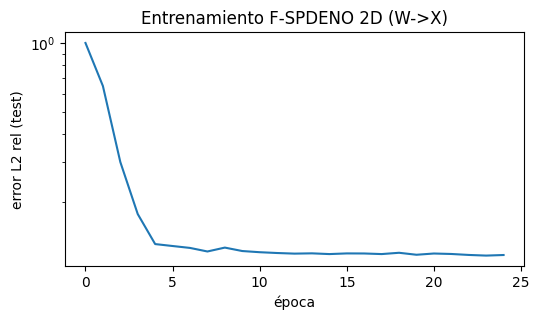

In [7]:
# ============ Baseline (campo medio) + Entrenamiento (Apéndice F.2) ============
# Baseline: predecir el campo medio de train. Si el modelo no lo bate, las features no aportan.
base_pred = Ytr.mean(0, keepdim=True).expand_as(Yte)
print(f"baseline (campo medio de train) rel_l2 = {rel_l2(base_pred, Yte).item():.4f}")

opt = torch.optim.Adam(net.parameters(), lr=LR, weight_decay=WD)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=5)
best, hist = float("inf"), []
for ep in range(EPOCHS):
    net.train(); perm = torch.randperm(N)
    for i in range(0, N, BS):
        idx = perm[i:i + BS]; opt.zero_grad()
        loss = rel_l2(reconstruir(net(make_input(Ftr_t[idx]))), Ytr[idx])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), GRAD_CLIP)
        opt.step()
    e_te = eval_batched(Fte_t, Yte); sched.step(e_te); hist.append(e_te)
    if e_te < best:
        best = e_te; torch.save(net.state_dict(), "ns_best_Wmap.pt")
    if ep % 5 == 0 or ep == EPOCHS - 1:
        print(f"época {ep:>3}: train={loss.item():.4f}  test={e_te:.4f}  lr={opt.param_groups[0]['lr']:.1e}")
print(f"\nMEJOR test = {best:.4f}")

fig, ax = plt.subplots(figsize=(5.5, 3.3))
ax.plot(hist); ax.set_yscale("log")
ax.set_xlabel("época"); ax.set_ylabel("error L2 rel (test)")
ax.set_title("Entrenamiento F-SPDENO 2D (W->X)")
plt.tight_layout(); plt.savefig("ns_train_Wmap.pdf"); plt.show()


Error L2 relativo de TEST (W->X): 0.1167
Referencia paper (Table 2, F-SPDENO, W->X): 0.037


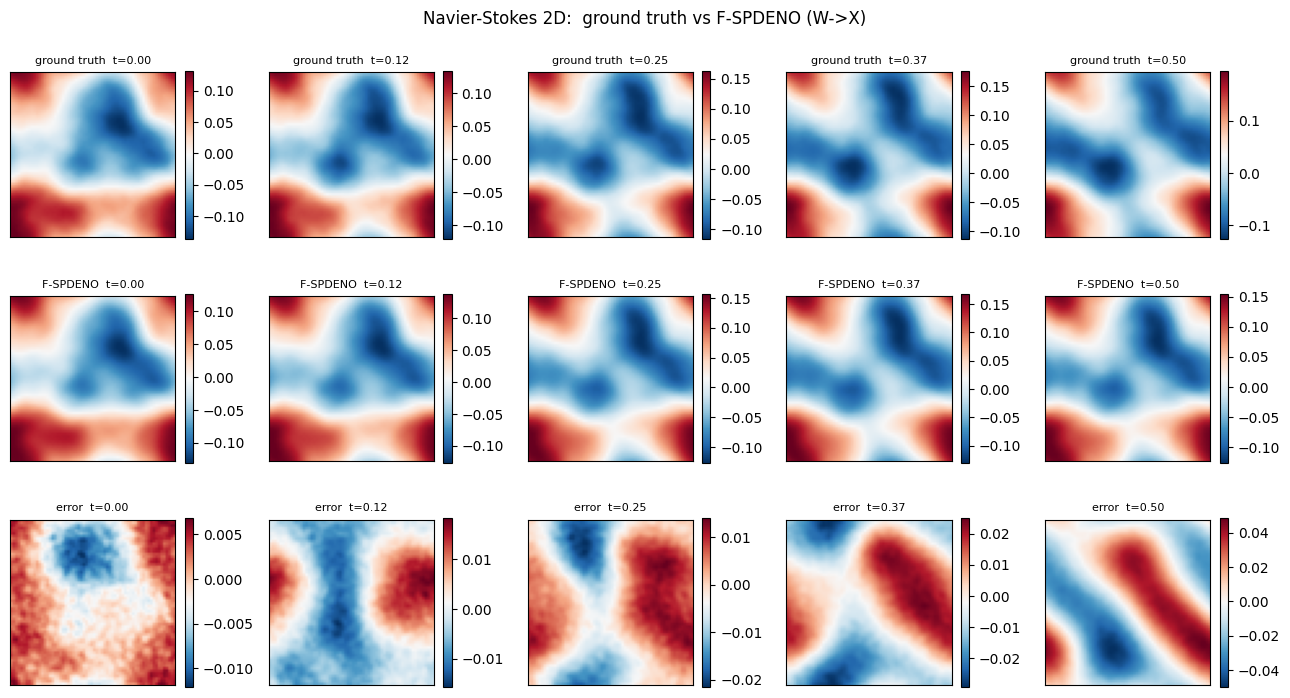

In [8]:
# ============ Evaluación (mejor modelo) + comparación Table 2 + figura tipo Fig. 3 ============
net.load_state_dict(torch.load("ns_best_Wmap.pt")); net.eval()
err = eval_batched(Fte_t, Yte)
print(f"Error L2 relativo de TEST (W->X): {err:.4f}")
print("Referencia paper (Table 2, F-SPDENO, W->X): 0.037")

with torch.no_grad():
    pred0 = reconstruir(net(make_input(Fte_t[:1])))[0].cpu().numpy()
gt0 = Yte[0].cpu().numpy()
idx = [int(k) for k in np.linspace(0, Nt, 5)]
fig, axs = plt.subplots(3, 5, figsize=(13, 7.2))
for col, ti in enumerate(idx):
    for row, (dat, ttl) in enumerate([(gt0, "ground truth"), (pred0, "F-SPDENO"),
                                       (gt0 - pred0, "error")]):
        im = axs[row, col].imshow(dat[ti], origin="lower", cmap="RdBu_r")
        axs[row, col].set_title(f"{ttl}  t={ti*dt_rec:.2f}", fontsize=8)
        axs[row, col].set_xticks([]); axs[row, col].set_yticks([])
        fig.colorbar(im, ax=axs[row, col], fraction=0.046)
plt.suptitle("Navier-Stokes 2D:  ground truth vs F-SPDENO (W->X)")
plt.tight_layout(); plt.savefig("ns_pred_Wmap.pdf"); plt.show()
